Ten skrypt tworzy zespół agentów AI, którzy współpracują aby realizować zadania programistyczne. Agenci automatycznie dzielą się rolami: planista opracowuje plan działania, programista pisze kod, wykonawca go uruchamia, kontrola jakości sprawdza wyniki, a administrator nadzoruje cały proces i zatwierdza plany.

# Setup

In [ ]:
!uv pip install -q autogen matplotlib

In [ ]:
from autogen.agentchat import (
    UserProxyAgent,
    AssistantAgent,
    GroupChat,
    GroupChatManager,
)

import networkx as nx
import matplotlib.pyplot as plt
import pprint
from google.colab import userdata

Ten kod importuje niezbędne moduły i biblioteki do działania programu. Rozbijmy to na części:

*   `from autogen.agentchat import UserProxyAgent,AssistantAgent,GroupChat,GroupChatManager`: Importuje klasy z biblioteki `autogen`, które są kluczowe dla tworzenia agentów konwersacyjnych i zarządzania ich interakcjami.
    *   `UserProxyAgent` reprezentuje agenta sterowanego przez użytkownika.
    *   `AssistantAgent` reprezentuje agenta działającego jako asystent, np. model językowy.
    *   `GroupChat` umożliwia tworzenie rozmów grupowych między agentami.
    *   `GroupChatManager` zarządza przebiegiem rozmowy grupowej i koordynuje działania agentów.

*   `import networkx as nx`: Importuje bibliotekę `networkx` jako `nx`.  NetworkX służy do tworzenia, manipulowania i analizy struktur sieciowych (grafów). Może być używana do wizualizacji relacji między agentami.

*   `import matplotlib.pyplot as plt`: Importuje moduł `pyplot` z biblioteki `matplotlib` jako `plt`.  Matplotlib służy do tworzenia wykresów i wizualizacji danych, w tym grafów sieciowych stworzonych za pomocą NetworkX.

In [ ]:
config_list = [{"model": "gpt-4.1", "api_key": userdata.get("openaivision")}]

model_config = {
    "cache_seed": 42,
    "temperature": 0,
    "config_list": config_list,
    "timeout": 120,
}

Ten kod definiuje konfigurację dla agentów wykorzystujących model językowy GPT-4.1:
*   `config_list = [{"model": "gpt-4.1", "api_key": userdata.get('openaivision')}]`: Tworzy listę słowników konfiguracyjnych dla agentów.
    *   `"model": "gpt-4o"`: Określa, że agenci będą korzystać z modelu językowego GPT-4.1 .

Pozostałe elementy konfiguracji:

*   `"cache_seed": 42`: Ustawia ziarno dla cache'owania w celu zapewnienia powtarzalności wyników.
*   `"temperature": 0`: Ustawia temperaturę na zero, co skutkuje bardziej deterministycznymi odpowiedziami modelu.
*   `"config_list": config_list`: Przypisuje listę konfiguracji agentów do słownika `model_config`.
*   `"timeout": 120`: Ustawia limit czasu odpowiedzi na 120 sekund.

Podsumowując, ten kod konfigurowany jest do użycia modelu GPT-4.1 z kluczem API pobranym z Google Colab userdata.

# Agenci

In [ ]:
# User Proxy Agent
user_proxy = UserProxyAgent(
    name="Admin",
    human_input_mode="ALWAYS",
    system_message="1. A human admin. 2. Interact with the team. 3. Plan execution needs to be approved by this Admin.",
    code_execution_config=False,
    llm_config=model_config,
    description="""Call this Agent if:
        You need guidance.
        The program is not working as expected.
        You need api key
        DO NOT CALL THIS AGENT IF:
        You need to execute the code.""",
)

# Assistant Agent - Developer
developer = AssistantAgent(
    name="Developer",
    llm_config=model_config,
    system_message="""You are an AI developer. You follow an approved plan, follow these guidelines:
    1. You write python/shell code to solve tasks.
    2. Wrap the code in a code block that specifies the script type.
    3. The user can't modify your code. So do not suggest incomplete code which requires others to modify.
    4. You should print the specific code you would like the executor to run.
    5. Don't include multiple code blocks in one response.
    6. If you need to import libraries, use ```bash pip install module_name```, please send a code block that installs these libraries and then send the script with the full implementation code
    7. Check the execution result returned by the executor,  If the result indicates there is an error, fix the error and output the code again
    8. Do not show appreciation in your responses, say only what is necessary.
    9. If the error can't be fixed or if the task is not solved even after the code is executed successfully, analyze the problem, revisit your assumption, collect additional info you need, and think of a different approach to try.
    """,
    description="""Call this Agent if:
        You need to write code.
        DO NOT CALL THIS AGENT IF:
        You need to execute the code.""",
)
# Assistant Agent - Planner
planner = AssistantAgent(
    name="Planner",  # 2. The research should be executed with code
    system_message="""You are an AI Planner,  follow these guidelines:
    1. Your plan should include 5 steps, you should provide a detailed plan to solve the task.
    2. Post project review isn't needed.
    3. Revise the plan based on feedback from admin and quality_assurance.
    4. The plan should include the various team members,  explain which step is performed by whom, for instance: the Developer should write code, the Executor should execute code, important do not include the admin in the tasks e.g ask the admin to research.
    5. Do not show appreciation in your responses, say only what is necessary.
    6. The final message should include an accurate answer to the user request
    """,
    llm_config=model_config,
    description="""Call this Agent if:
        You need to build a plan.
        DO NOT CALL THIS AGENT IF:
        You need to execute the code.""",
)

# User Proxy Agent - Executor
executor = UserProxyAgent(
    name="Executor",
    system_message="1. You are the code executer. 2. Execute the code written by the developer and report the result.3. you should read the developer request and execute the required code",
    human_input_mode="NEVER",
    code_execution_config={
        "last_n_messages": 20,
        "work_dir": "dream",
        "use_docker": True,
    },
    description="""Call this Agent if:
        You need to execute the code written by the developer.
        You need to execute the last script.
        You have an import issue.
        DO NOT CALL THIS AGENT IF:
        You need to modify code""",
)
quality_assurance = AssistantAgent(
    name="Quality_assurance",
    system_message="""You are an AI Quality Assurance. Follow these instructions:
      1. Double check the plan,
      2. if there's a bug or error suggest a resolution
      3. If the task is not solved, analyze the problem, revisit your assumption, collect additional info you need, and think of a different approach.""",
    llm_config=model_config,
)

Ten kod definiuje pięć agentów konwersacyjnych w ramach systemu AutoGen, każdy z określoną rolą i konfiguracją.

**1. `user_proxy` (Admin):**
*   `system_message="..."`: Definiuje rolę i zachowanie agenta jako administratora, który nadzoruje proces, wymaga akceptacji planów wykonania i służy jako punkt kontaktowy dla zespołu.
*   `code_execution_config=False`: Agent nie może wykonywać kodu bezpośrednio.
*   `description="..."`: Opisuje, kiedy należy wezwać tego agenta – gdy potrzebna jest pomoc, program nie działa poprawnie lub wymagany jest klucz API.  Wyraźnie zaznacza, że nie należy go wywoływać do wykonywania kodu.

**2. `developer` (Developer):**
*   `system_message="..."`: Definiuje rolę agenta jako programisty AI, który pisze kod w Pythonie i shellu, aby rozwiązywać zadania.  Instrukcje obejmują formatowanie kodu, unikanie niekompletnych fragmentów, instalację bibliotek za pomocą `pip`, sprawdzanie wyników wykonania i analizę błędów.
*   `description="..."`: Opisuje, kiedy należy wezwać tego agenta – gdy potrzebne jest napisanie kodu.  Wyraźnie zaznacza, że nie należy go wywoływać do wykonywania kodu.

**3. `planner` (Planner):**
*   `system_message="..."`: Definiuje rolę agenta jako planisty AI, który tworzy szczegółowe plany działania składające się z 5 kroków.  Plan powinien uwzględniać podział zadań między członków zespołu (Developer, Executor) i unikać angażowania administratora w zadania operacyjne.
*   `description="..."`: Opisuje, kiedy należy wezwać tego agenta – gdy potrzebne jest opracowanie planu działania.  Wyraźnie zaznacza, że nie należy go wywoływać do wykonywania kodu.

**4. `executor` (Executor):**
*   `system_message="..."`: Definiuje rolę agenta jako wykonawcy kodu, który uruchamia kod dostarczony przez programistę i raportuje wyniki.
*   `human_input_mode="NEVER"`: Agent nigdy nie oczekuje na interakcję od użytkownika (działa automatycznie).
*   `code_execution_config="..."`: Konfiguracja środowiska wykonawczego kodu, w tym historia wiadomości (`last_n_messages`), katalog roboczy (`work_dir`) i użycie Dockera (`use_docker`).
*   `description="..."`: Opisuje, kiedy należy wezwać tego agenta – gdy potrzebne jest uruchomienie kodu.  Wyraźnie zaznacza, że nie należy go wywoływać do modyfikacji kodu.

**5. `quality_assurance` (Quality_assurance):**
*   `system_message="..."`: Definiuje rolę agenta jako osoby odpowiedzialnej za kontrolę jakości, która sprawdza plany, sugeruje poprawki w przypadku błędów i analizuje problemy, jeśli zadanie nie zostanie rozwiązane.

In [ ]:
allowed_transitions = {
    user_proxy: [planner, quality_assurance],
    planner: [user_proxy, developer, quality_assurance],
    developer: [executor, quality_assurance, user_proxy],
    executor: [developer],
    quality_assurance: [planner, developer, executor, user_proxy],
}

Ten kod definiuje dozwolone przejścia (interakcje) między agentami w systemie AutoGen. Słownik `allowed_transitions` określa, które agenty mogą komunikować się z którymi innymi agentami.

*   Klucze słownika reprezentują agentów (np. `user_proxy`, `planner`).
*   Wartości dla każdego klucza to listy innych agentów, do których dany agent może wysyłać wiadomości lub wywoływać ich funkcje.

Rozbijmy to na poszczególne przejścia:

*   `user_proxy: [ planner,quality_assurance]`: Administrator (User Proxy) może komunikować się z Planistą i Kontrolą Jakości.
*   `planner: [ user_proxy, developer, quality_assurance]`: Planista może komunikować się z Administratorem, Programistą i Kontrolą Jakości.
*   `developer: [executor,quality_assurance, user_proxy]`: Programista może komunikować się z Wykonawcą, Kontrolą Jakości i Administratorem.
*   `executor: [developer]`: Wykonawca może komunikować się tylko z Programistą.
*   `quality_assurance: [planner,developer,executor,user_proxy]`: Kontrola Jakości może komunikować się z wszystkimi agentami – Planistą, Programistą, Wykonawcą i Administratorem.

Oznacza to, że system AutoGen będzie ograniczał interakcje między agentami tylko do tych określonych w tym słowniku. Na przykład, Wykonawca nie może bezpośrednio komunikować się z Planistą ani Kontrolą Jakości; musi przejść przez Programistę.  To pomaga kontrolować przepływ informacji i zapewnia bardziej uporządkowaną współpracę między agentami.

In [ ]:
system_message_manager = "You are the manager of a research group your role is to manage the team and make sure the project is completed successfully."

groupchat = GroupChat(
    agents=[user_proxy, developer, planner, executor, quality_assurance],
    allowed_or_disallowed_speaker_transitions=allowed_transitions,
    speaker_transitions_type="allowed",
    messages=[],
    max_round=50,
    send_introductions=True,
)

manager = GroupChatManager(
    groupchat=groupchat, llm_config=model_config, system_message=system_message_manager
)

Ten kod tworzy i konfiguruje grupę czatu oraz menedżera zarządzającego tą grupą.

*   `system_message_manager="You are the manager of a research group your role is to manage the team and make sure the project is completed successfully."`: Definiuje wiadomość systemową dla menedżera grupy, określającą jego rolę jako osoby odpowiedzialnej za zarządzanie zespołem i zapewnienie pomyślnego zakończenia projektu.

*   `groupchat = GroupChat(...)`: Tworzy obiekt `GroupChat`, który reprezentuje rozmowę grupową między agentami.
    *   `agents=[user_proxy, developer, planner, executor, quality_assurance]`: Określa listę agentów biorących udział w rozmowie grupowej.
    *   `allowed_or_disallowed_speaker_transitions=allowed_transitions`: Ustawia dozwolone przejścia między mówcami (agentami) na podstawie wcześniej zdefiniowanego słownika `allowed_transitions`.
    *   `speaker_transitions_type="allowed"`: Określa, że używane są tylko *dozwolone* przejścia. Oznacza to, że agent może odpowiedzieć tylko innemu agentowi, jeśli taka interakcja jest określona w `allowed_transitions`.
    *   `messages=[]`: Inicjalizuje listę wiadomości jako pustą.  Rozmowa rozpoczyna się od zera wiadomości.
    *   `max_round = 50`: Ustawia maksymalną liczbę rund rozmowy na 50. Po przekroczeniu tej liczby, rozmowa zostanie zakończona.
    *   `send_introductions=True`:  Powoduje, że agenci przedstawią się nawzajem na początku rozmowy.

*   `manager = GroupChatManager(...)`: Tworzy obiekt `GroupChatManager`, który zarządza przebiegiem rozmowy grupowej.
    *   `groupchat=groupchat`: Przypisuje wcześniej utworzony obiekt `GroupChat` do menedżera.
    *   `llm_config = model_config`: Używa wcześniej zdefiniowanej konfiguracji modelu językowego dla wszystkich agentów w grupie.
    *   `system_message = system_message_manager`: Przypisuje wiadomość systemową dla menedżera, określając jego rolę i obowiązki.

W efekcie tego kodu tworzony jest system rozmowy grupowej z jasno zdefiniowanymi rolami agentów, dozwolonymi interakcjami oraz mechanizmem zarządzania prowadzonym przez dedykowanego menedżera.

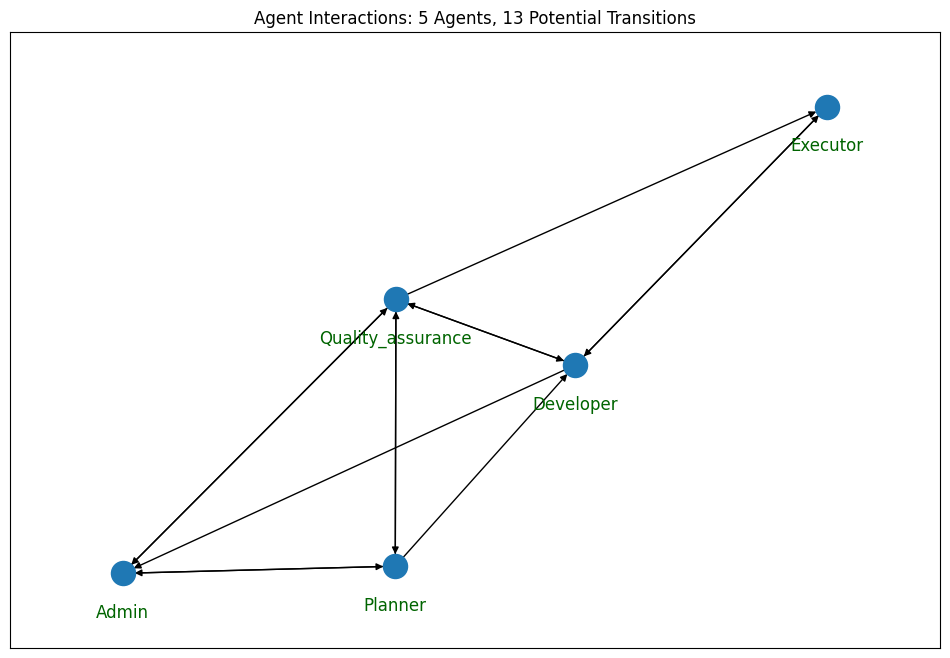

In [ ]:
G = nx.DiGraph()

# Add nodes
G.add_nodes_from([agent.name for agent in groupchat.agents])

# Add edges
for key, value in allowed_transitions.items():
    for agent in value:
        G.add_edge(key.name, agent.name)

# Set the figure size
plt.figure(figsize=(12, 8))

# Visualize
pos = nx.spring_layout(G)  # For consistent positioning

# Draw nodes and edges
nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_edges(G, pos)

# Draw labels below the nodes
label_pos = {
    k: [v[0], v[1] - 0.1] for k, v in pos.items()
}  # Shift labels below the nodes
nx.draw_networkx_labels(G, label_pos, verticalalignment="top", font_color="darkgreen")

# Adding margins
ax = plt.gca()
ax.margins(0.1)  # Increase the margin value if needed


# Adding a dynamic title
total_transitions = sum(len(v) for v in allowed_transitions.values())
title = f"Agent Interactions: {len(groupchat.agents)} Agents, {total_transitions} Potential Transitions"
plt.title(title)

plt.show()

# Test

In [ ]:
task1 = "what are the 5 leading GitHub repositories on llm for the legal domain?"

chat_result = user_proxy.initiate_chat(manager, message=task1, clear_history=True)

Admin (to chat_manager):

what are the 5 leading GitHub repositories on llm for the legal domain?

--------------------------------------------------------------------------------

Next speaker: Planner

Planner (to chat_manager):

Step 1: Researcher identifies the criteria for "leading" GitHub repositories (e.g., stars, activity, relevance to LLMs and legal domain).

Step 2: Researcher searches GitHub using relevant keywords (e.g., "legal LLM", "law large language model", "legal NLP", "legal AI") and filters repositories based on the criteria.

Step 3: Researcher reviews the top repositories, examining their descriptions, activity, and community engagement to ensure they are focused on LLMs in the legal domain.

Step 4: Researcher compiles a list of the 5 leading repositories, including their names, links, and a brief description of each.

Step 5: Researcher presents the final list to the user.

--------------------------------------------------------------------------------

Next spe

In [28]:
pprint.pprint(chat_result.cost)

{'usage_excluding_cached_inference': {'total_cost': 0},
 'usage_including_cached_inference': {'total_cost': 0}}
